In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
from torch.utils.data import Dataset, Subset
from pathlib import Path
import numpy as np
import torch

class BoreasRadarDataset(Dataset):
    def __init__(self, data_dir, patches_per_frame=400):
        self.data_dir = Path(data_dir)
        self.patches_per_frame = patches_per_frame
        
        # Grab sorted lists of the batched arrays
        self.patch_files = sorted(list((self.data_dir / "input/patch_arrays_2.0_deg").glob("*.npy")))
        self.label_files = sorted(list((self.data_dir / "filtered_labels").glob("*.npy")))
        
        self.num_frames = len(self.patch_files)
        print(f"Found {self.num_frames} frames. Total samples: {self.__len__()}")
        
        # ==========================================
        # CALCULATE GLOBAL MAXIMUM FOR NORMALIZATION
        # ==========================================
        print("Scanning dataset for global maximum reflectivity...")
        global_max = 0.0
        for label_file in self.label_files:
            # Memory map the file to avoid loading it entirely into RAM
            batched_labels = np.load(label_file, mmap_mode='r')
            file_max = batched_labels.max()
            if file_max > global_max:
                global_max = file_max
                
        # Save it to the class instance (adding a tiny epsilon to prevent division by zero)
        self.global_max = float(global_max) + 1e-8
        print(f"Global max radar reflectivity found: {self.global_max:.4f}")
        
    def __len__(self):
        return self.num_frames * self.patches_per_frame
        
    def __getitem__(self, idx):
        # Locate the correct file and sub-index
        frame_idx = idx // self.patches_per_frame
        patch_idx = idx % self.patches_per_frame
        
        # Memory map the specific arrays
        batched_patches = np.load(self.patch_files[frame_idx], mmap_mode='r')
        batched_labels = np.load(self.label_files[frame_idx], mmap_mode='r')
        
        # Extract to RAM and convert to 32-bit floats
        # Adding a channel dimension [1, 50, 50] for the CNN
        patch = np.expand_dims(batched_patches[patch_idx].copy(), axis=0).astype(np.float32)
        label = batched_labels[patch_idx].copy().astype(np.float32)
        
        # ==========================================
        # APPLY GLOBAL NORMALIZATION
        # ==========================================
        label = label / self.global_max
        
        return torch.from_numpy(patch), torch.from_numpy(label)

In [3]:
dataset = BoreasRadarDataset(data_dir="/media/asrl/Extreme SSD/ASRL/boreas/data/boreas-2024-12-03-12-54")
sample_dataset = Subset(dataset, range(0, 136 * 400))
dataloader = DataLoader(sample_dataset, batch_size=32, shuffle=True, num_workers=4)
patches, targets = next(iter(dataloader))
print("Batch shape:", patches.shape) # Should be [32, 1, 50, 50]
input_size = patches.shape[-1]

Found 3843 frames. Total samples: 1537200
Scanning dataset for global maximum reflectivity...
Global max radar reflectivity found: 0.5609
Batch shape: torch.Size([32, 1, 21, 21])


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RadarTranslatorCNN(nn.Module):
    def __init__(self, output_bins=6848):
        super().__init__()

        # -------- 2D encoder: [B,1,21,21] -> latent --------
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # 21x21
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # 21 -> 10

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 10x10
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # 10 -> 5

            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 5x5
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )

        flattened_dim = 128 * 5 * 5

        # 6848 = 107 * 64, so seed length 107 then upsample x2 six times
        self.fc = nn.Linear(flattened_dim, 128 * 107)

        # -------- 1D decoder --------
        self.decoder = nn.Sequential(
            # 107 -> 214
            nn.ConvTranspose1d(128, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),

            # 214 -> 428
            nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),

            # 428 -> 856
            nn.ConvTranspose1d(64, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),

            # 856 -> 1712
            nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),

            # 1712 -> 3424
            nn.ConvTranspose1d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(inplace=True),

            # 3424 -> 6848
            nn.ConvTranspose1d(16, 8, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(8),
            nn.ReLU(inplace=True),

            # refine locally
            nn.Conv1d(8, 8, kernel_size=5, padding=2),
            nn.BatchNorm1d(8),
            nn.ReLU(inplace=True),

            nn.Conv1d(8, 1, kernel_size=5, padding=2)
        )

    def forward(self, x):
        x = self.encoder(x)                # [B,256,5,5]
        x = torch.flatten(x, start_dim=1)  # [B, 3200]
        x = self.fc(x)                     # [B, 13696]
        x = x.view(x.size(0), 128, 107)    # [B, 128, 107]
        
        x = self.decoder(x)                # [B, 1, 6848]
        x = x.squeeze(1)                   # [B, 6848]
        return x

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RadarTranslatorCNN().to(device)
dummy_input = torch.randn(32, 1, 21, 21).to(device)
output = model(dummy_input)
print("Output shape:", output.shape) # Should be [32, 6848]

Output shape: torch.Size([32, 6848])


In [6]:
class PeakWeightedShapeLoss(nn.Module):
    def __init__(self, threshold=0.25, alpha=50.0, gamma=10.0, grad_weight=0.6, eps=1e-6):
        super().__init__()
        self.threshold = threshold
        self.alpha = alpha
        self.gamma = gamma
        self.grad_weight = grad_weight
        self.eps = eps

    def forward(self, pred, target):
        # pred, target: [B, L]

        # Per-sample max so weighting adapts to each waveform
        target_max = target.amax(dim=1, keepdim=True)

        # Normalize only the amount above threshold
        above = torch.clamp(target - self.threshold, min=0.0)
        scale = torch.clamp(target_max - self.threshold, min=self.eps)
        rel_peak = above / scale   # 0 below threshold, up to ~1 at tallest peak

        # Weight grows with peak height
        weights = 1.0 + self.alpha * (rel_peak ** self.gamma)

        # Amplitude loss
        amp_loss = (weights * (pred - target) ** 2).mean()

        # Gradient / shape loss
        pred_grad = pred[:, 1:] - pred[:, :-1]
        target_grad = target[:, 1:] - target[:, :-1]
        grad_loss = ((pred_grad - target_grad) ** 2).mean()

        return amp_loss + self.grad_weight * grad_loss

In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CoVisibilityLoss(nn.Module):
    def __init__(self, window_size=7, negative_ratio=5):
        """
        window_size: How many bins to expand the LiDAR signal (must be odd, e.g., 1, 3, 5)
        negative_ratio: Number of empty bins to sample per positive bin
        """
        super().__init__()
        self.window_size = window_size
        self.negative_ratio = negative_ratio
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, predictions, lidar_waveform, radar_waveform):
        """
        predictions: Model outputs before sigmoid (Batch, 6848)
        lidar_waveform: Output from your depth_to_waveform function (Batch, 6848)
        radar_waveform: The filtered ground truth radar polar image (Batch, 6848)
        """
        B, L = predictions.shape
        device = predictions.device

        lidar_mask = lidar_waveform > 1e-2
        # radar_mask = radar_waveform > 1e-2
        # positive_centers = lidar_mask & radar_mask
        positive_centers = lidar_mask

        centers_unsqueeze = positive_centers.unsqueeze(1).float()
        pad = self.window_size // 2

        roi_mask = F.max_pool1d(
            centers_unsqueeze, 
            kernel_size=self.window_size, 
            stride=1, 
            padding=pad
        ).squeeze(1).bool()

        candidate_neg_mask = (~roi_mask)

        num_pos = lidar_mask.sum(dim=1, keepdim=True)
        pos_budget = (num_pos * self.negative_ratio).clamp(min=self.negative_ratio * 2.0)
        empty_budget = torch.ones_like(num_pos) * (100.0 * self.negative_ratio)
        num_neg_to_keep = torch.where(num_pos > 0, pos_budget, empty_budget)
        
        # Calculate the probability of keeping a candidate
        num_candidates = candidate_neg_mask.sum(dim=1, keepdim=True).clamp(min=1)
        prob = (num_neg_to_keep / num_candidates).clamp(max=1.0)
        
        # Generate a random tensor and apply the probability threshold
        random_roll = torch.rand_like(predictions, dtype=torch.float32)
        sampled_neg_mask = candidate_neg_mask & (random_roll < prob)

        loss_mask = roi_mask | sampled_neg_mask

        targets = torch.zeros(
            (B, L), 
            dtype=torch.float32, 
            device=device
        )
        # targets[roi_mask] = radar_waveform[roi_mask]
        targets[lidar_mask] = lidar_waveform[lidar_mask]

        raw_loss = self.bce(predictions, targets)
        valid_loss = raw_loss[loss_mask]

        if valid_loss.numel() == 0:
            return torch.tensor(0.0, device=device, requires_grad=True)
            
        return valid_loss.mean()

In [40]:
def get_gaussian_kernel(window_size=15, sigma=3.0, device='cpu'):
    """Creates a 1D Gaussian kernel for smoothing."""
    # Create an array centered around zero
    x = torch.arange(window_size, dtype=torch.float32, device=device)
    x = x - window_size // 2
    
    # Calculate the Gaussian curve
    kernel = torch.exp(-(x ** 2) / (2 * sigma ** 2))
    
    # Normalize so the peak is exactly 1.0 
    # (If you want it to sum to 1.0 instead, divide by kernel.sum())
    kernel = kernel / kernel.max()
    
    # Reshape for conv1d: (out_channels, in_channels, sequence_length)
    return kernel.view(1, 1, -1)

In [41]:
import torch

def depth_to_waveform(nonzero_depths, resolution=0.04381, bins=6848, window_size=25, sigma=3):
    device = nonzero_depths.device
    waveform = torch.zeros(bins, dtype=torch.float32, device=device)
    
    if nonzero_depths.numel() == 0:
        return waveform

    # Divide by resolution, round to the nearest whole number, and subtract 1
    indices = torch.round(nonzero_depths / resolution).long()
    
    # Filter out out-of-bounds indices 
    # (including depths < 0.5 * resolution which would become index -1)
    valid_mask = (indices >= 0) & (indices < bins)
    valid_indices = indices[valid_mask]
    # print(valid_indices)
    
    waveform[valid_indices] = 1.0
    
    # Smooth with Gaussian Kernel
    waveform_view = waveform.view(1, 1, -1)
    kernel = get_gaussian_kernel(window_size, sigma, device)
    pad = window_size // 2
    smoothed_waveform = F.conv1d(waveform_view, kernel, padding=pad)
    smoothed_waveform = torch.clamp(smoothed_waveform, max=1.0)
    
    return smoothed_waveform.view(-1)

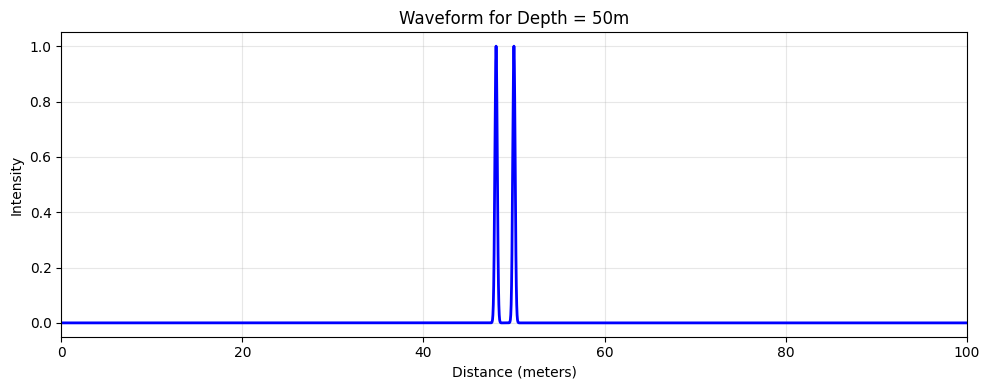

In [42]:
import torch
import matplotlib.pyplot as plt

# Your test point
test_depth = torch.tensor([50.0, 48.0])

# Generate the waveform (assuming your function is defined above this cell)
waveform = depth_to_waveform(test_depth)

# Generate the X-axis distances (assuming default resolution)
resolution = 0.04381
bins = len(waveform)
distances = torch.arange(bins) * resolution

# Plotting
plt.figure(figsize=(10, 4))
plt.plot(distances.numpy(), waveform.cpu().numpy(), color='blue', linewidth=2)

# Zoom in exactly around the 50m mark to see the shape clearly
plt.xlim(0.0, 100.0) 
plt.title("Waveform for Depth = 50m")
plt.xlabel("Distance (meters)")
plt.ylabel("Intensity")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
def batch_depth_to_waveforms(patches, bins=6848, resolution=0.04381, depth_channel=0):
    """
    patches: torch.Tensor of shape [B, C, H, W]
    returns: torch.Tensor of shape [B, bins]
    """
    waveforms = []

    # use only the depth/range channel
    depth_patches = patches[:, depth_channel]   # [B, H, W]

    for patch in depth_patches:
        nonzero_depths = patch[patch != 0]
        wf = depth_to_waveform(nonzero_depths, resolution=resolution, bins=bins)
        waveforms.append(wf)

    return torch.stack(waveforms, dim=0)

In [44]:
# 1. Device configuration (Using your RTX A4500!)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Dynamically get the required output size from the first label
# (Assuming 'dataset' is already initialized from your previous cell)
sample_patch, sample_label = dataset[0]
num_radar_bins = sample_label.shape[0]

Using device: cuda


In [ ]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader

# 3. Initialize the network with the correct bin size and move it to the GPU
model = RadarTranslatorCNN(output_bins=num_radar_bins).to(device)

# 4. Define the Optimizer and Loss Function
optimizer = optim.Adam(model.parameters(), lr=0.001)
# criterion = PeakWeightedShapeLoss()
criterion = CoVisibilityLoss(window_size=7, negative_ratio=5).to(device)

# 5. THE OVERFIT SETUP: Grab exactly ONE batch and hold it in memory
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
overfit_patches, overfit_labels = next(iter(dataloader))

# Move this specific batch to the GPU permanently so it doesn't transfer every loop
overfit_patches = overfit_patches.to(device)
overfit_labels = overfit_labels.to(device)

print(f"Grabbed 1 batch of {overfit_patches.shape[0]} samples.")
print(f"Patch shape: {overfit_patches.shape} | Label shape: {overfit_labels.shape}")

# 6. The Overfitting Loop
num_epochs = 1000 # Run enough epochs to force memorization

print("Starting overfitting test...")

with torch.no_grad(): # We don't want gradients flowing through the masking logic
    lidar_waveforms = batch_depth_to_waveforms(overfit_patches) # Shape: [B, 6848]

for epoch in range(num_epochs):
    model.train() 
    
    # Step A: Zero out the gradients
    optimizer.zero_grad()
    
    # Step B: Forward Pass
    predictions = model(overfit_patches)
    
    # Step C: Calculate the Loss
    # loss = criterion(predictions, overfit_labels)
    loss = criterion(
            predictions=predictions,
            lidar_waveform=lidar_waveforms,
            radar_waveform=overfit_labels
        )
    
    # Step D: Backward Pass
    loss.backward()
    
    # Step E: Optimize (Update weights)
    optimizer.step()
    
    # Print an update every 20 epochs to watch it drop
    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {loss.item():.6f}")

print("Overfitting test complete!")

Grabbed 1 batch of 32 samples.
Patch shape: torch.Size([32, 1, 21, 21]) | Label shape: torch.Size([32, 6848])
Starting overfitting test...
Epoch [1/1000] | Loss: 0.749625
Epoch [20/1000] | Loss: 0.496183
Epoch [40/1000] | Loss: 0.387634
Epoch [60/1000] | Loss: 0.294902
Epoch [80/1000] | Loss: 0.209656
Epoch [100/1000] | Loss: 0.147266
Epoch [120/1000] | Loss: 0.117626
Epoch [140/1000] | Loss: 0.098888
Epoch [160/1000] | Loss: 0.084529
Epoch [180/1000] | Loss: 0.074213
Epoch [200/1000] | Loss: 0.066718
Epoch [220/1000] | Loss: 0.060659
Epoch [240/1000] | Loss: 0.055743
Epoch [260/1000] | Loss: 0.052455
Epoch [280/1000] | Loss: 0.049096
Epoch [300/1000] | Loss: 0.047660
Epoch [320/1000] | Loss: 0.044888
Epoch [340/1000] | Loss: 0.043143
Epoch [360/1000] | Loss: 0.041634
Epoch [380/1000] | Loss: 0.040383
Epoch [400/1000] | Loss: 0.040055
Epoch [420/1000] | Loss: 0.038560
Epoch [440/1000] | Loss: 0.037637
Epoch [460/1000] | Loss: 0.037006
Epoch [480/1000] | Loss: 0.036224
Epoch [500/1000] 

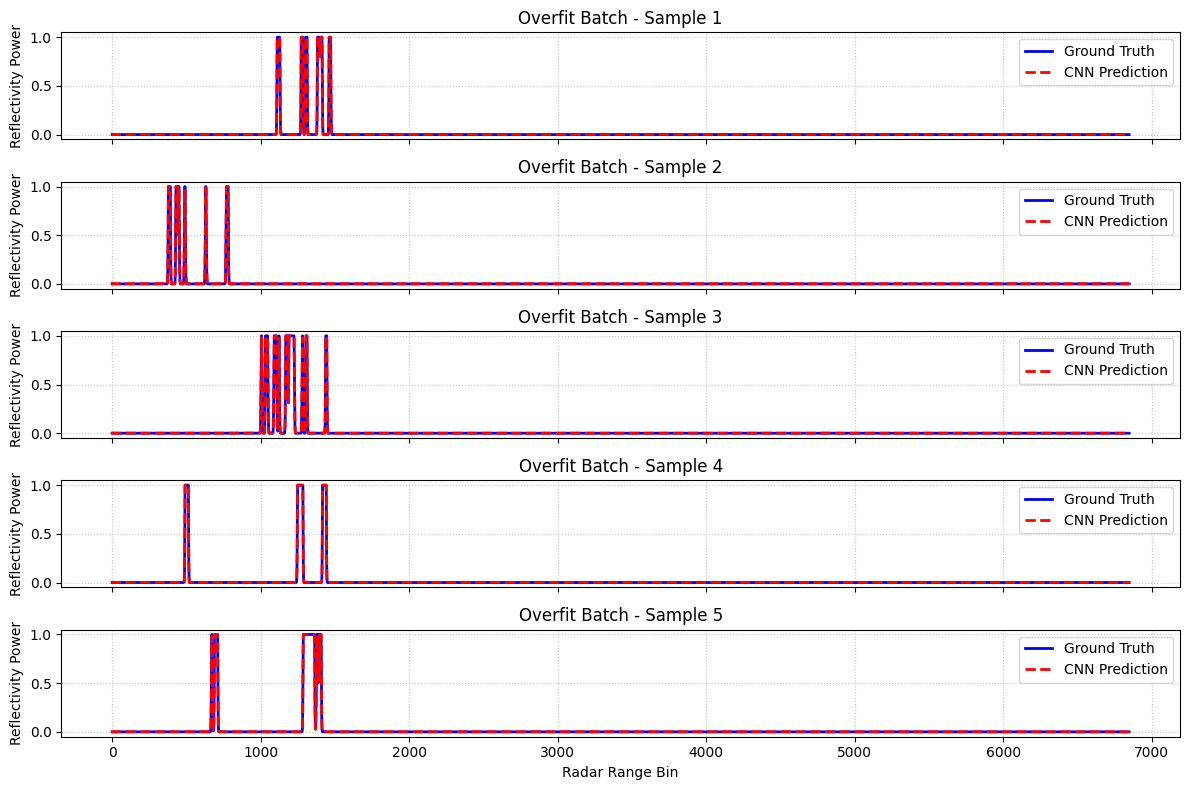

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Set the model to evaluation mode (Crucial for inference!)
model.eval()

# 2. Run the forward pass without tracking gradients (saves memory/time)
with torch.no_grad():
    final_preds = torch.sigmoid(model(overfit_patches))

# 3. Move the data off the GPU and convert to NumPy
preds_np = final_preds.cpu().numpy()
labels_np = overfit_labels.cpu().numpy()
lidar_np = lidar_waveforms.cpu().numpy()

# 4. Set up a Matplotlib figure to plot 3 different examples from the batch
num_examples = 5
fig, axes = plt.subplots(num_examples, 1, figsize=(12, 8), sharex=True)

for i in range(num_examples):
    ax = axes[i]
    
    # Plot Ground Truth in Blue
    # ax.plot(labels_np[i], label="Ground Truth", color='blue', linewidth=2)
    ax.plot(lidar_np[i], label="Ground Truth", color='blue', linewidth=2)
    
    # Plot Prediction in Red (Dashed so you can see the blue underneath)
    ax.plot(preds_np[i], label="CNN Prediction", color='red', linestyle='--', linewidth=2)
    
    ax.set_title(f"Overfit Batch - Sample {i+1}")
    ax.set_ylabel("Reflectivity Power")
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend()

# Format the bottom X-axis
axes[-1].set_xlabel("Radar Range Bin")
plt.tight_layout()
plt.show()

In [48]:
dataset_size = len(sample_dataset)
print(dataset_size)

54400


Epoch [1000/1000] | Train Loss: 0.00825 | Valid Loss: 0.61423


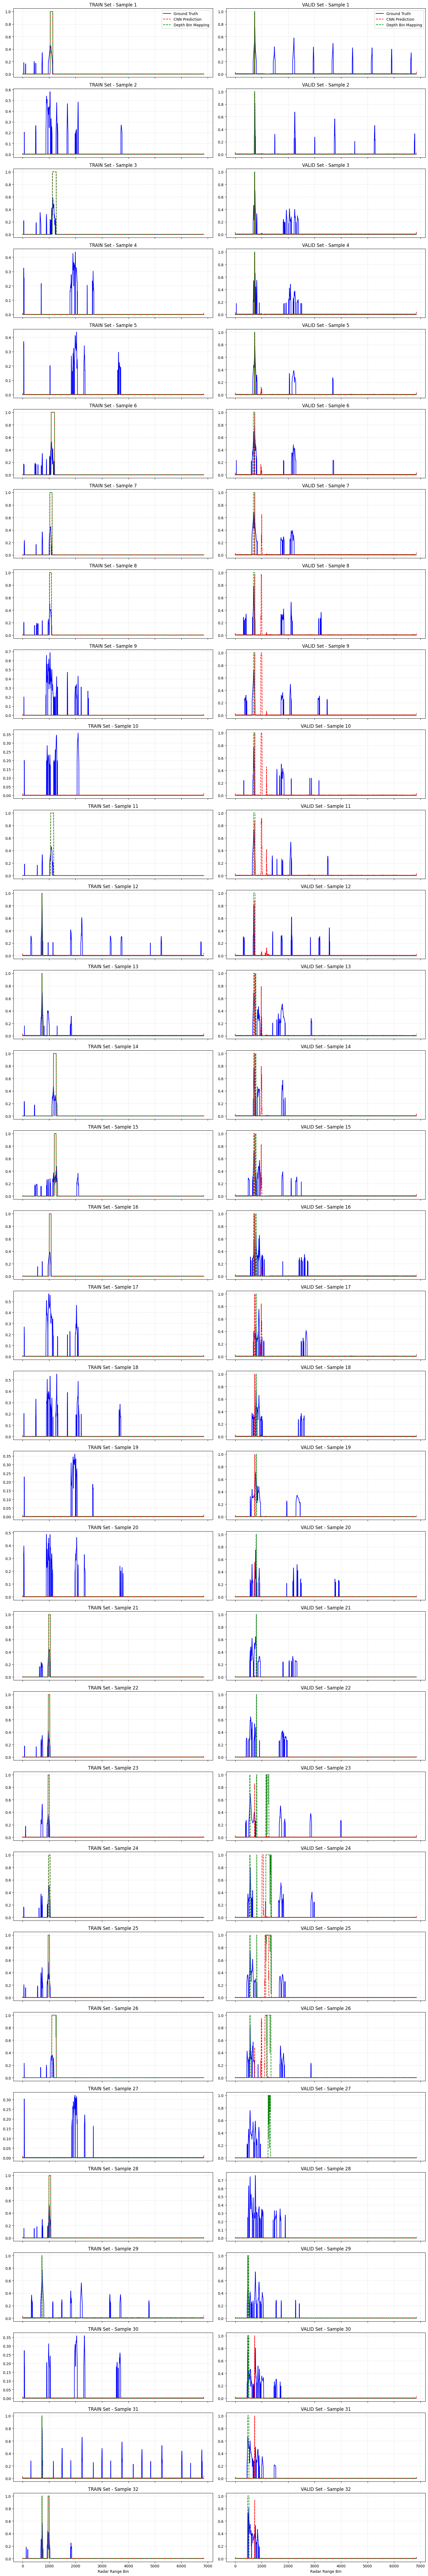

Training Complete!


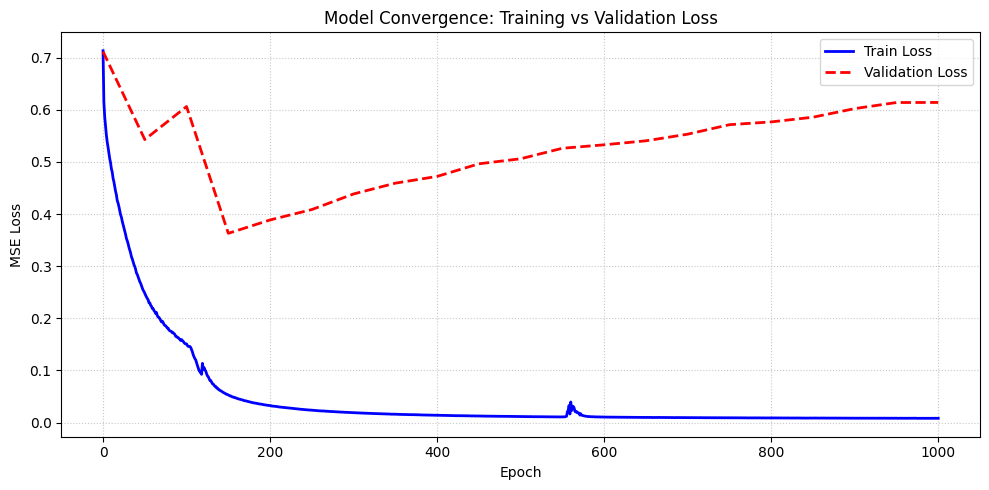

In [59]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import IPython.display as display
import numpy as np

# ==========================================
# 1. CHRONOLOGICAL DATASET SPLITTING (BY FRAME)
# ==========================================
azimuths_per_frame = 400
total_frames = len(dataset) // azimuths_per_frame

# train_frames = int(0.70 * total_frames)
# valid_frames = int(0.15 * total_frames)
train_frames = int(1)
valid_frames = int(1)
test_frames = total_frames - train_frames - valid_frames

# train_end_idx = train_frames * azimuths_per_frame
# valid_end_idx = train_end_idx + (valid_frames * azimuths_per_frame)
train_end_idx = 32
valid_end_idx = train_end_idx + 32

train_dataset = Subset(dataset, range(0, train_end_idx))
valid_dataset = Subset(dataset, range(train_end_idx, valid_end_idx))
test_dataset  = Subset(dataset, range(valid_end_idx, len(dataset)))

print(f"Total Frames: {total_frames}")
print(f"Frame Split -> Train: {train_frames} | Valid: {valid_frames} | Test: {test_frames}")
print(f"Patch Split -> Train: {len(train_dataset)} | Valid: {len(valid_dataset)} | Test: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ==========================================
# 2. MODEL & HYPERPARAMETER SETUP
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(1000)  # put seed BEFORE model creation
model = RadarTranslatorCNN(output_bins=num_radar_bins).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
# criterion = PeakWeightedShapeLoss()
criterion = CoVisibilityLoss(window_size=7, negative_ratio=5).to(device)

num_epochs = 1000
plot_every_n_epochs = 50
samples_to_plot = 32

history_train_loss = []
history_valid_loss = []

# ==========================================
# 2.5 GRAB FIXED BATCHES FOR PLOTTING
# ==========================================
fixed_train_patches, fixed_train_labels = next(iter(train_loader))
fixed_valid_patches, fixed_valid_labels = next(iter(valid_loader))

fixed_train_patches = fixed_train_patches.to(device)
fixed_valid_patches = fixed_valid_patches.to(device)

fixed_train_labels_np = fixed_train_labels.numpy()
fixed_valid_labels_np = fixed_valid_labels.numpy()

fixed_train_depth_waveforms_np = batch_depth_to_waveforms(
    fixed_train_patches, bins=num_radar_bins, resolution=0.04381, depth_channel=0
).cpu().numpy()

fixed_valid_depth_waveforms_np = batch_depth_to_waveforms(
    fixed_valid_patches, bins=num_radar_bins, resolution=0.04381, depth_channel=0
).cpu().numpy()

# ==========================================
# 2.75 INITIAL LOSS BEFORE TRAINING
# ==========================================
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for patches, labels in loader:
            patches = patches.to(device)
            labels = labels.to(device)

            preds = model(patches)
            
            # 1. Generate the LiDAR prior for the validation batch
            lidar_waveforms = batch_depth_to_waveforms(patches)
            
            # 2. Call the custom loss with all 3 arguments
            loss = criterion(
                predictions=preds,
                lidar_waveform=lidar_waveforms,
                radar_waveform=labels
            )
            
            total_loss += loss.item()

    return total_loss / len(loader)

initial_train_loss = evaluate_loss(model, train_loader, criterion, device)
initial_valid_loss = evaluate_loss(model, valid_loader, criterion, device)

history_train_loss.append(initial_train_loss)
history_valid_loss.append(initial_valid_loss)

print(f"Initial Model | Train Loss: {initial_train_loss:.5f} | Valid Loss: {initial_valid_loss:.5f}")

# Optional: plot initial predictions before any training
with torch.no_grad():
    train_preds_np = torch.sigmoid(model(fixed_train_patches)).cpu().numpy()
    valid_preds_np = torch.sigmoid(model(fixed_valid_patches)).cpu().numpy()

fig, axes = plt.subplots(samples_to_plot, 2, figsize=(16, 3 * samples_to_plot), sharex=True)
if samples_to_plot == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(samples_to_plot):
    ax_train = axes[i, 0]
    ax_train.plot(fixed_train_labels_np[i], label="Ground Truth", color='blue', linewidth=1.5)
    ax_train.plot(train_preds_np[i], label="CNN Prediction", color='red', linestyle='--', linewidth=1.5)
    ax_train.set_title(f"INITIAL TRAIN Set - Sample {i+1}")
    ax_train.grid(True, linestyle=':', alpha=0.7)
    if i == 0:
        ax_train.legend()

    ax_valid = axes[i, 1]
    ax_valid.plot(fixed_valid_labels_np[i], label="Ground Truth", color='blue', linewidth=1.5)
    ax_valid.plot(valid_preds_np[i], label="CNN Prediction", color='red', linestyle='--', linewidth=1.5)
    ax_valid.set_title(f"INITIAL VALID Set - Sample {i+1}")
    ax_valid.grid(True, linestyle=':', alpha=0.7)
    if i == 0:
        ax_valid.legend()

axes[-1, 0].set_xlabel("Radar Range Bin")
axes[-1, 1].set_xlabel("Radar Range Bin")
plt.tight_layout()
plt.show()

# ==========================================
# 3. TRAINING & VALIDATION LOOP
# ==========================================
print("Starting Full Training with Side-by-Side Monitoring...")

best_valid_loss = float('inf')
for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0.0

    for patches, labels in train_loader:
        patches = patches.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        predictions = model(patches)

        with torch.no_grad():
            lidar_waveforms = batch_depth_to_waveforms(patches)

        # loss = criterion(predictions, labels)
        loss = criterion(
            predictions=predictions,
            lidar_waveform=lidar_waveforms,
            radar_waveform=labels
        )
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    history_train_loss.append(avg_train_loss)

    # --- VALIDATION & PLOTTING PHASE ---
    if (epoch + 1) % plot_every_n_epochs == 0:
        avg_valid_loss = evaluate_loss(model, valid_loader, criterion, device)
        history_valid_loss.append(avg_valid_loss)

        with torch.no_grad():
            train_preds_np = torch.sigmoid(model(fixed_train_patches)).cpu().numpy()
            valid_preds_np = torch.sigmoid(model(fixed_valid_patches)).cpu().numpy()

        display.clear_output(wait=True)

        if avg_valid_loss < best_valid_loss:
            best_valid_loss = avg_valid_loss
            
            # ==========================================
            # SAVE THE CURRENT MODEL
            # ==========================================
            save_path = "../model_weights/baseline.pth"
            torch.save(model.state_dict(), save_path)
            print(f"Model successfully saved to {save_path}")

        fig, axes = plt.subplots(samples_to_plot, 2, figsize=(16, 3 * samples_to_plot), sharex=True)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.5f} | Valid Loss: {avg_valid_loss:.5f}")

        if samples_to_plot == 1:
            axes = np.expand_dims(axes, axis=0)

        for i in range(samples_to_plot):
            ax_train = axes[i, 0]
            ax_train.plot(fixed_train_labels_np[i], label="Ground Truth", color='blue', linewidth=1.5)
            ax_train.plot(train_preds_np[i], label="CNN Prediction", color='red', linestyle='--', linewidth=1.5)
            ax_train.plot(fixed_train_depth_waveforms_np[i], label="Depth Bin Mapping", color='green', linestyle='--', linewidth=1.5)
            ax_train.set_title(f"TRAIN Set - Sample {i+1}")
            ax_train.grid(True, linestyle=':', alpha=0.7)
            if i == 0:
                ax_train.legend()

            ax_valid = axes[i, 1]
            ax_valid.plot(fixed_valid_labels_np[i], label="Ground Truth", color='blue', linewidth=1.5)
            ax_valid.plot(valid_preds_np[i], label="CNN Prediction", color='red', linestyle='--', linewidth=1.5)
            ax_valid.plot(fixed_valid_depth_waveforms_np[i], label="Depth Bin Mapping", color='green', linestyle='--', linewidth=1.5)
            ax_valid.set_title(f"VALID Set - Sample {i+1}")
            ax_valid.grid(True, linestyle=':', alpha=0.7)
            if i == 0:
                ax_valid.legend()

        axes[-1, 0].set_xlabel("Radar Range Bin")
        axes[-1, 1].set_xlabel("Radar Range Bin")
        plt.tight_layout()
        plt.show()

print("Training Complete!")

# ==========================================
# 4. FINAL LOSS CURVE PLOT
# ==========================================
plt.figure(figsize=(10, 5))

# x-axis now includes epoch 0 = initial untrained model
train_x_axis = list(range(0, num_epochs + 1))
valid_x_axis = list(range(0, num_epochs + 1, plot_every_n_epochs))

plt.plot(train_x_axis, history_train_loss, label='Train Loss', color='blue', linewidth=2)
plt.plot(valid_x_axis, history_valid_loss, label='Validation Loss', color='red', linestyle='--', linewidth=2)

plt.title("Model Convergence: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [13]:
# ==========================================
# SAVE THE CURRENT MODEL
# ==========================================
save_path = "../model_weights/baseline_1D_decoder_last_epoch.pth"
torch.save(model.state_dict(), save_path)
print(f"Model successfully saved to {save_path}")

Model successfully saved to ../model_weights/baseline_1D_decoder_last_epoch.pth


In [10]:
import torch

# 1. Recreate the empty architecture
# Make sure to use the exact same class and parameters you trained with!
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RadarTranslatorCNN(output_bins=6848).to(device)

# 2. Define the path where you saved it
save_path = "../model_weights/baseline.pth"

# 3. Load the weights dictionary from the file
# (weights_only=True is a security best practice in newer PyTorch versions)
state_dict = torch.load(save_path, map_location=device, weights_only=True)

# 4. Pour the weights into the empty model
model.load_state_dict(state_dict)

# 5. Set to evaluation mode! 
# This turns off Dropout and locks BatchNorm layers so your predictions are deterministic.
model.eval()

print("Model successfully loaded and ready for inference!")

Model successfully loaded and ready for inference!


In [ ]:
# ==========================================
# 2. RUN INFERENCE ON THE ENTIRE TEST SET
# ==========================================
print("Running inference on the test set...")
model.eval()

all_test_preds = []
all_test_labels = []
test_loss = 0.0

with torch.no_grad():
    for patches, labels in test_loader:
        patches = patches.to(device)
        
        # --- PREDICTION ---
        # If using the OLD single-head model:
        preds = model(patches)
        
        # If using the NEW Two-Headed model, uncomment this:
        # prob_preds, int_preds = model(patches)
        # preds = prob_preds * int_preds 
        
        # Calculate test loss (using whatever criterion you defined)
        
        # Move back to CPU and store
        all_test_preds.append(preds.cpu().numpy())
        all_test_labels.append(labels.numpy())

# Concatenate into massive flat arrays of shape (Total_Samples, 6848)
all_test_preds_np = np.concatenate(all_test_preds, axis=0)
all_test_labels_np = np.concatenate(all_test_labels, axis=0)

# ==========================================
# 3. RECONSTRUCT THE FULL POLAR FRAMES
# ==========================================
# Assuming exactly 400 azimuths per frame based on the Boreas dataset
azimuths_per_frame = 400

# Calculate how many full frames we have (drop any weird partial remainders)
num_full_frames = all_test_preds_np.shape[0] // azimuths_per_frame

# Reshape from (N, 6848) to (Frames, 400, 6848)
polar_preds = all_test_preds_np[:num_full_frames * azimuths_per_frame].reshape(num_full_frames, azimuths_per_frame, -1)
polar_labels = all_test_labels_np[:num_full_frames * azimuths_per_frame].reshape(num_full_frames, azimuths_per_frame, -1)

print(f"Successfully reconstructed {num_full_frames} full Polar Radar frames!")
print(f"Polar array shape: {polar_preds.shape}")

# ==========================================
# 4. PLOT 1D WAVEFORM EXAMPLES
# ==========================================
samples_to_plot = 5
fig, axes = plt.subplots(samples_to_plot, 1, figsize=(16, 30), sharex=True)

for i in range(samples_to_plot):
    ax = axes[i]
    ax.plot(all_test_labels_np[i], label="Ground Truth", color='blue', linewidth=1.5)
    ax.plot(all_test_preds_np[i], label="Model Prediction", color='red', linestyle='--', linewidth=1.5)
    
    ax.set_title(f"Test Set - 1D Waveform Sample {i+1}")
    ax.set_ylabel("Reflectivity")
    ax.grid(True, linestyle=':', alpha=0.7)
    if i == 0: ax.legend(loc="upper right")

axes[-1].set_xlabel("Radar Range Bin")
plt.tight_layout()
plt.show()

In [12]:
from pyboreas import BoreasDataset
import os

dataset = BoreasRadarDataset(data_dir="/media/asrl/Extreme SSD/ASRL/boreas/data/boreas-2024-12-03-12-54")
dataloader = DataLoader(dataset, batch_size=400, shuffle=False, num_workers=4)
patches, targets = next(iter(dataloader))
input_size = patches.shape[-1]
print("Batch shape:", patches.shape)
print("Label shape:", targets.shape)

Found 136 frames. Total samples: 54400
Batch shape: torch.Size([400, 1, 21, 21])
Label shape: torch.Size([400, 6848])


In [13]:
# Grab the user's home directory
boreas_data = os.getenv("SSD")
boreas_data = os.path.join(boreas_data, "ASRL/boreas/data")
bd = BoreasDataset(boreas_data)
seq = bd.sequences[0]

radar_start_frame = 65
radar_end_frame = 200
radar_frame_idx = radar_start_frame
radar_start_ts = None
radar_end_ts = None

In [14]:
# Run inference on every frame
all_preds = []
all_labels = []

with torch.no_grad():   
    for patches, labels in dataloader:
        patches = patches.to(device)
        preds = model(patches)

        # Use Boreas util functions
        radar_frame = seq.get_radar(radar_frame_idx)

        # ---------------------------------------------------------
        # 1. Generate and Save the Label Image
        # ---------------------------------------------------------
        radar_frame.polar = labels.numpy()
        cart_label = radar_frame.polar_to_cart(cart_resolution=0.2384, cart_pixel_width=640, in_place=False)

        fig1 = plt.figure(figsize=(10,10), dpi=100)
        ax1 = fig1.add_subplot()
        ax1.imshow(cart_label, cmap="gray")
        ax1.set_axis_off()

        label_filename = f"../../postprocessing/radar_labels_filtered/{radar_frame.frame}.png"
        # bbox_inches='tight' and pad_inches=0 aggressively strip the white borders
        fig1.savefig(label_filename, bbox_inches='tight', pad_inches=0)

        # CRITICAL: Free the memory so your computer doesn't crash!
        plt.close(fig1) 


        # ---------------------------------------------------------
        # 2. Generate and Save the Prediction Image
        # ---------------------------------------------------------
        radar_frame.polar = preds.cpu().numpy()
        cart_pred = radar_frame.polar_to_cart(cart_resolution=0.2384, cart_pixel_width=640, in_place=False)

        fig2 = plt.figure(figsize=(10,10), dpi=100)
        ax2 = fig2.add_subplot()
        ax2.imshow(cart_pred, cmap="gray")
        ax2.set_axis_off()

        pred_filename = f"../../postprocessing/radar_preds_filtered/{radar_frame.frame}.png"
        fig2.savefig(pred_filename, bbox_inches='tight', pad_inches=0)

        # CRITICAL: Free the memory!
        plt.close(fig2)
        radar_frame.unload_data()

        radar_frame_idx += 1

In [ ]:
# Example demonstrating that we can get jacobian from pytorch

def f(x):
    return torch.stack([
        x[0]**2 + x[1],
        x[0] * x[1]
    ])

x = torch.tensor([3.0, 4.0], requires_grad=True)

J = torch.autograd.functional.jacobian(f, x)
print(J)
print(J.shape)

tensor([[6., 1.],
        [4., 3.]])
torch.Size([2, 2])
